In [1]:
import common_functions

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import numpy as np
import rioxarray as rxr
import xarray as xr
from pyproj import CRS, Transformer
import os
import rasterio

In [2]:
dust_points_vars = pd.read_csv("DATA/processed/3_dust_points_vars_2026-06-22.csv")
location_name = "American Southwest"

In [3]:
def add_squares_to_plot(ax, color="white", linewidth=3):

    regions = {
        "Region 1": [(31.75, -108.00), (31.00, -107.25)],  # 369 events
        "Region 2": [(31.05, -107.20), (30.30, -106.45)],  # 205 events
        "Region 3": [(40.25, -118.70), (39.50, -117.95)],  # 161 events
        "Region 4": [(41.00, -119.75), (40.25, -119.00)],  # 140 events
        "Region 5": [(33.30, -102.65), (32.55, -101.90)],  # 139 events
        "Region 6": [(30.80, -108.00), (30.05, -107.25)],  # 112 events
        "Region 7": [(31.80, -107.25), (31.05, -106.50)],  # 94 events
        "Region 8": [(31.60, -108.75), (30.85, -108.00)],  # 86 events
        "Region 9": [(34.15, -103.10), (33.40, -102.35)],  # 79 events
        "Region 10": [(35.85, -111.25), (35.10, -110.50)],  # 76 events
        "Region 11": [(29.50, -107.00), (28.75, -106.25)],  # 76 events
        "Region 12": [(33.00, -106.90), (32.25, -106.15)],  # 61 events
        "Region 13": [(32.55, -102.25), (31.80, -101.50)],  # 58 events
        "Region 14": [(37.00, -110.25), (36.25, -109.50)],  # 57 events
        "Region 15": [(36.45, -108.95), (35.70, -108.20)],  # 55 events
        "Region 16": [(38.15, -106.30), (37.40, -105.55)],  # 55 events
        "Region 17": [(33.40, -103.40), (32.65, -102.65)],  # 54 events
        "Region 18": [(32.55, -108.05), (31.80, -107.30)],  # 53 events
        "Region 19": [(38.15, -118.15), (37.40, -117.40)],  # 49 events
        "Region 20": [(39.15, -113.35), (38.40, -112.60)],  # 37 events
        "Region 21": [(32.45, -110.10), (31.70, -109.35)],  # 36 events
        "Region 22": [(29.85, -107.95), (29.10, -107.20)],  # 35 events
        "Region 23": [(28.75, -107.15), (28.00, -106.40)],  # 34 events
        "Region 24": [(42.00, -117.30), (41.25, -116.55)],  # 32 events
        "Region 25": [(34.70, -103.85), (33.95, -103.10)],  # 31 events
        "Region 26": [(31.25, -105.15), (30.50, -104.40)],  # 29 events
        "Region 27": [(38.55, -104.65), (37.80, -103.90)],  # 29 events
        "Region 28": [(38.60, -103.40), (37.85, -102.65)],  # 29 events
        "Region 29": [(33.30, -101.90), (32.55, -101.15)],  # 29 events
        "Region 30": [(41.45, -119.00), (40.70, -118.25)],  # 27 events
        "Region 31": [(30.80, -106.45), (30.05, -105.70)],  # 26 events
        "Region 32": [(29.30, -105.10), (28.55, -104.35)],  # 26 events
        "Region 33": [(35.55, -116.80), (34.80, -116.05)],  # 25 events
        "Region 34": [(34.05, -102.35), (33.30, -101.60)],  # 25 events
        "Region 35": [(29.65, -106.25), (28.90, -105.50)],  # 24 events
        "Region 36": [(32.55, -115.70), (31.80, -114.95)],  # 23 events
        "Region 37": [(36.60, -111.70), (35.85, -110.95)],  # 23 events
        "Region 38": [(27.20, -104.30), (26.45, -103.55)],  # 22 events
        "Region 39": [(31.45, -103.85), (30.70, -103.10)],  # 22 events
        "Region 40": [(32.55, -103.00), (31.80, -102.25)],  # 21 events
        "Region 41": [(40.70, -120.50), (39.95, -119.75)],  # 19 events
        "Region 42": [(35.30, -110.50), (34.55, -109.75)],  # 19 events
        "Region 43": [(34.50, -116.00), (33.75, -115.25)],  # 18 events
        "Region 44": [(33.25, -116.45), (32.50, -115.70)],  # 17 events
    }

    for name, ((lat1, lon1), (lat2, lon2)) in regions.items():

        min_lat = min(lat1, lat2)
        max_lat = max(lat1, lat2)
        min_lon = min(lon1, lon2)
        max_lon = max(lon1, lon2)
        
        width = max_lon - min_lon
        height = max_lat - min_lat
        
        rect = patches.Rectangle(
            (min_lon, min_lat),
            width,
            height,
            linewidth=linewidth,
            edgecolor=color,
            facecolor='none',
            zorder=9,
            transform=ccrs.PlateCarree()
        )
        
        ax.add_patch(rect)

    return

In [4]:
def add_north_arrow(ax, location=(0.063, 0.9)):
    ax.annotate(
        'N',
        xy=location, xytext=(location[0],location[1]-.15),
        arrowprops=dict(facecolor='black', width=5, headwidth=15),
        ha='center',
        va='center',
        fontsize=12,
        xycoords='axes fraction',
        zorder=6
    )

def add_scale_bar(ax, length_km=300, location=(-0.21, 0.7)):
    """
    length_km: scale bar length in kilometers
    location: axes fraction (x, y)
    """
    # Approx conversion at mid-latitudes (good enough for visualization)
    km_per_deg = 111

    length_deg = length_km / km_per_deg

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x_start = xlim[0] + location[0] * (xlim[1] - xlim[0])
    y_start = ylim[0] + location[1] * (ylim[1] - ylim[0])

    ax.hlines(
        y=y_start,
        xmin=x_start,
        xmax=x_start + length_deg,
        colors='black',
        linewidth=3,
        transform=ccrs.PlateCarree(),
        zorder=6
    )

    ax.text(
        x_start + length_deg / 2,
        y_start + 0.5,
        f'{length_km} km',
        ha='center',
        transform=ccrs.PlateCarree(),
        zorder=6
    )


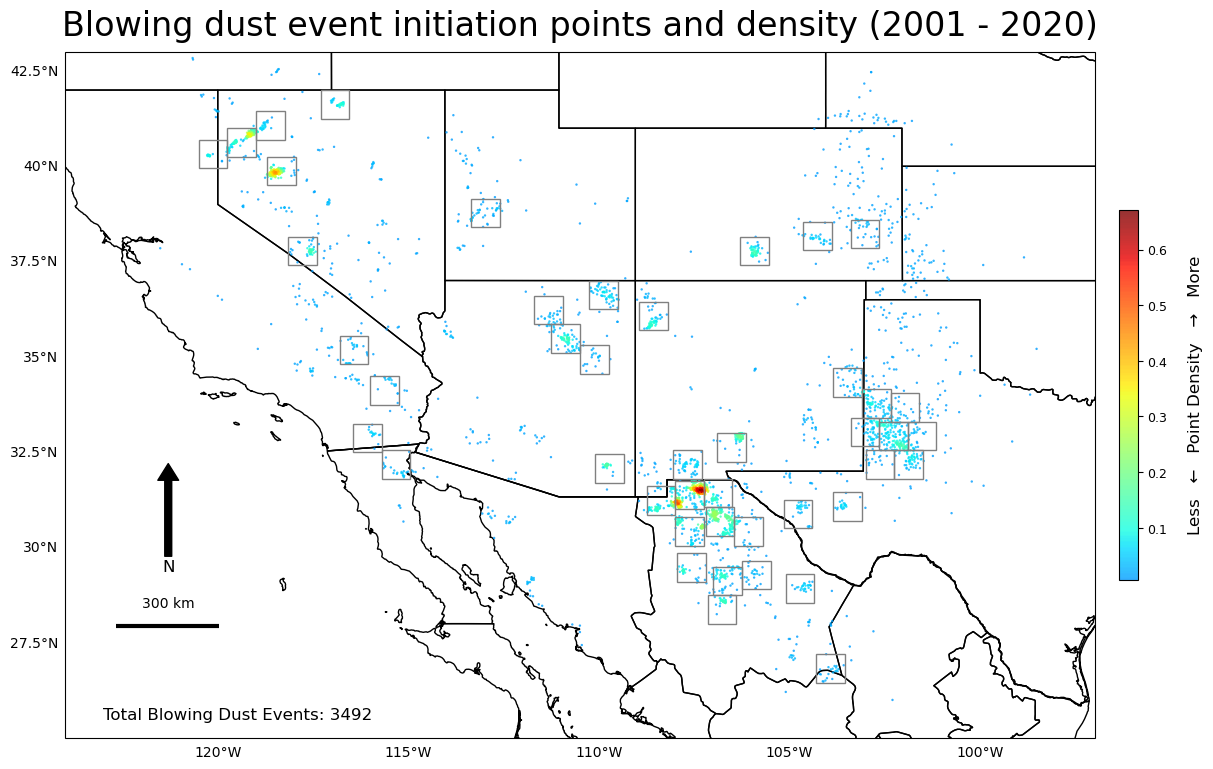

In [5]:
fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()},)

from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

# KDE Density
kde = gaussian_kde([dust_points_vars["longitude"], dust_points_vars["latitude"]], bw_method=0.02)
x = dust_points_vars["longitude"]
y = dust_points_vars["latitude"]
z = kde([x, y])
z = np.array(z)
colors = plt.cm.jet(np.linspace(0.28, 1.0, 256))
custom_cmap = LinearSegmentedColormap.from_list('custom', colors)
norm = plt.Normalize(vmin=z.min(), vmax=z.max())
scatter = ax.scatter(x, y, c=z, cmap=custom_cmap, s=3, edgecolors='none', alpha=0.8, norm=norm, zorder=6)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Point Density', shrink=0.4, pad=0.02)
cbar.set_label('Less   ←   Point Density   →   More', fontsize=12, labelpad=15)
cbar.ax.tick_params(labelsize=9)

#--- Add total number of events
total_events = len(dust_points_vars)
ax.text(-123, 25.5, f'Total Blowing Dust Events: {total_events}', fontsize=12)


add_squares_to_plot(ax, color="grey", linewidth=1)
add_north_arrow(ax, location=(0.1, 0.4))
add_scale_bar(ax, location=(0.0, 0.15))

ax.set_title("Blowing dust event initiation points and density (2001 - 2020)", fontsize=24, pad=12)

all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
name='admin_1_states_provinces', scale='10m', facecolor='none')
ax.add_feature(all_states_provinces, edgecolor='black', linewidth=1, zorder=2)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=1, zorder=2)
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)

min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False

plt.savefig(f"plots/0_dust_points_squares.png",
        dpi=600, bbox_inches='tight')
plt.show()

In [6]:
gldas_path = "DATA/raw/gldas_soil_texture/GLDASp5_soiltexture_025d.nc4"
texture_ds = xr.open_dataset(gldas_path)
lat_min, lat_max, lon_min, lon_max = common_functions._get_coords_for_region(location_name)

filtered_ds = texture_ds.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

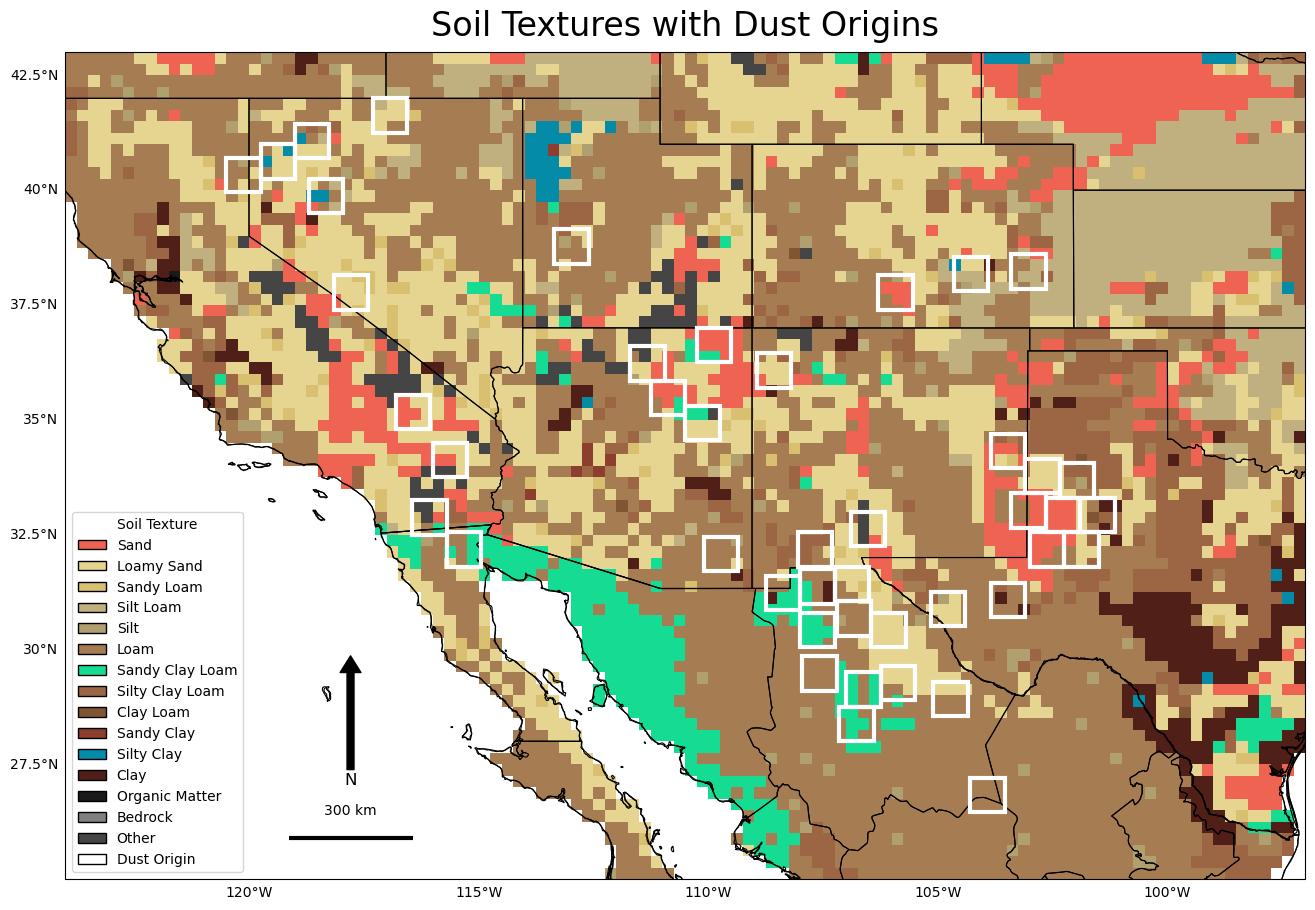

In [7]:
soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()

fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()})

texture_da = filtered_ds.GLDAS_soiltex

texture_da.plot(
    ax=ax,
    cmap=soil_cmap,
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)

add_squares_to_plot(ax)
add_north_arrow(ax, location=(0.23, 0.27))
add_scale_bar(ax, location=(0.18, 0.05))

all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
    name='admin_1_states_provinces', scale='10m', facecolor='none')
ax.add_feature(all_states_provinces, edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.8)
min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Soil Textures with Dust Origins", fontsize=24, pad=12)
legend_handles = [
    Patch(facecolor=color, edgecolor="black", label=label)
    for label, color in zip(texture_dict.values(), texture_colors)
]

dust_handle = Patch(
    facecolor="white",
    edgecolor="black",
    label="Dust Origin"
)
ax.legend(
    handles=legend_handles + [dust_handle],
    title="Soil Texture",
    loc="lower left",
    frameon=True
)

plt.savefig(f"plots/3_texture_0_map.png",
            dpi=600, bbox_inches='tight')
plt.show()

In [16]:
#--- Open soil order data
soil_da = xr.open_dataarray('DATA/raw/soil_orders_usda/soil_major_orders_2026-06-22.nc')

#--- Get soil order names and associated colormap
soil_order_dict = common_functions.get_soil_order_names_major()
soil_order_colors = common_functions.get_soil_order_colors_major()

codes = sorted(soil_order_dict.keys())
colors = [soil_order_colors[c] for c in codes]
soil_cmap = mcolors.ListedColormap(colors)

bounds = np.append(codes, codes[-1] + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, soil_cmap.N)

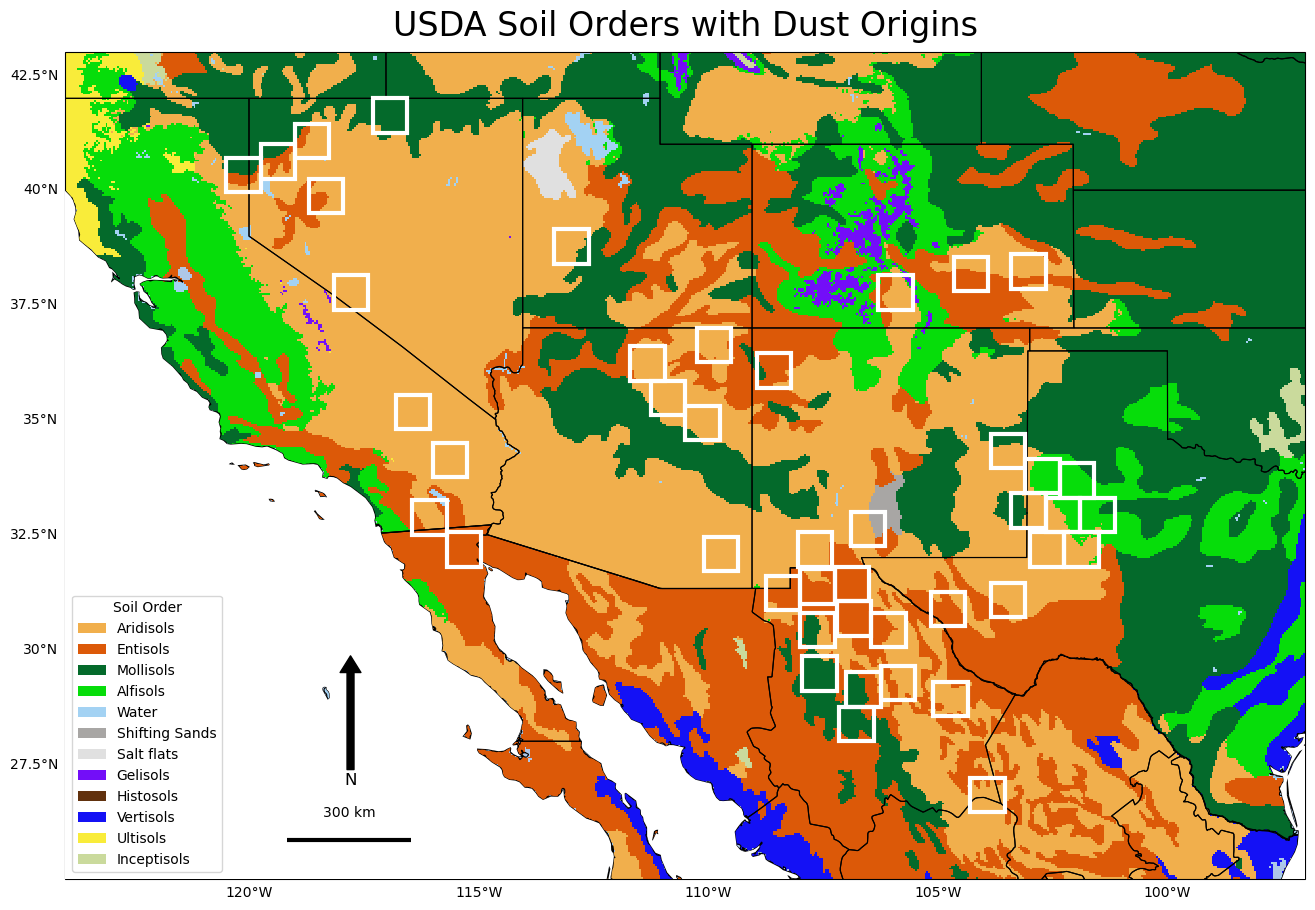

In [20]:

fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()})

soil_da.plot(
    ax=ax,
    cmap=soil_cmap,
    norm=norm,
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)

add_squares_to_plot(ax)
add_north_arrow(ax, location=(0.23, 0.27))
add_scale_bar(ax, location=(0.18, 0.05))


all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
    name='admin_1_states_provinces', scale='10m', facecolor='none')
ax.add_feature(all_states_provinces, edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=3)
min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False

ax.set_title("USDA Soil Orders with Dust Origins", fontsize=24, pad=12)

codes_legend = [2, 3, 7, 0, 15, 14, 13, 4, 5, 11, 10, 6]
legend_handles = [
    Patch(
        facecolor=soil_order_colors[code],
        label=soil_order_dict[code]
    )
    for code in codes_legend
]
ax.legend(
    handles=legend_handles,
    title="Soil Order",
    loc="lower left"
)

plt.savefig(f"plots/4_soil_types_usda_0_map.png",
            dpi=600, bbox_inches='tight')
plt.show()


In [10]:
def get_cec_land_cover_reprojection(cec_full, location_name):
    min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
    min_lat_extend = min_lat - 5
    max_lat_extend = max_lat + 4

    src_crs = CRS.from_epsg(4326) 
    dst_crs = CRS.from_wkt(cec_full.rio.crs.to_wkt()) 
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True) 
    minx, miny = transformer.transform(min_lon, min_lat_extend) 
    maxx, maxy = transformer.transform(max_lon, max_lat_extend) 
    minx, maxx = sorted([minx, maxx]) 
    miny, maxy = sorted([miny, maxy]) 
    cec_cropped = cec_full.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

    output_path = "DATA/processed/cec_land_cover/cec_land_cover_SW_epsg4326.tif"
    if not os.path.exists(output_path):
        print("Reprojecting to lat/lon...") 
        cec = cec_cropped.rio.reproject( 
            "EPSG:4326", 
            resolution=0.05, 
            resampling=rasterio.enums.Resampling.nearest)
        cec.rio.to_raster(output_path)
    else:
        print("Processed raster already exists — skipping reprojection.")
        cec = rxr.open_rasterio(output_path).squeeze("band", drop=True)

    return cec

In [11]:
cec_filepath = ("DATA/raw/cec_land_cover/NA_NALCMS_landcover_2020v2_30m/data/NA_NALCMS_landcover_2020v2_30m.tif")
cec_full = rxr.open_rasterio(cec_filepath).squeeze("band", drop=True)
cec_ds = get_cec_land_cover_reprojection(cec_full, location_name)

Processed raster already exists — skipping reprojection.


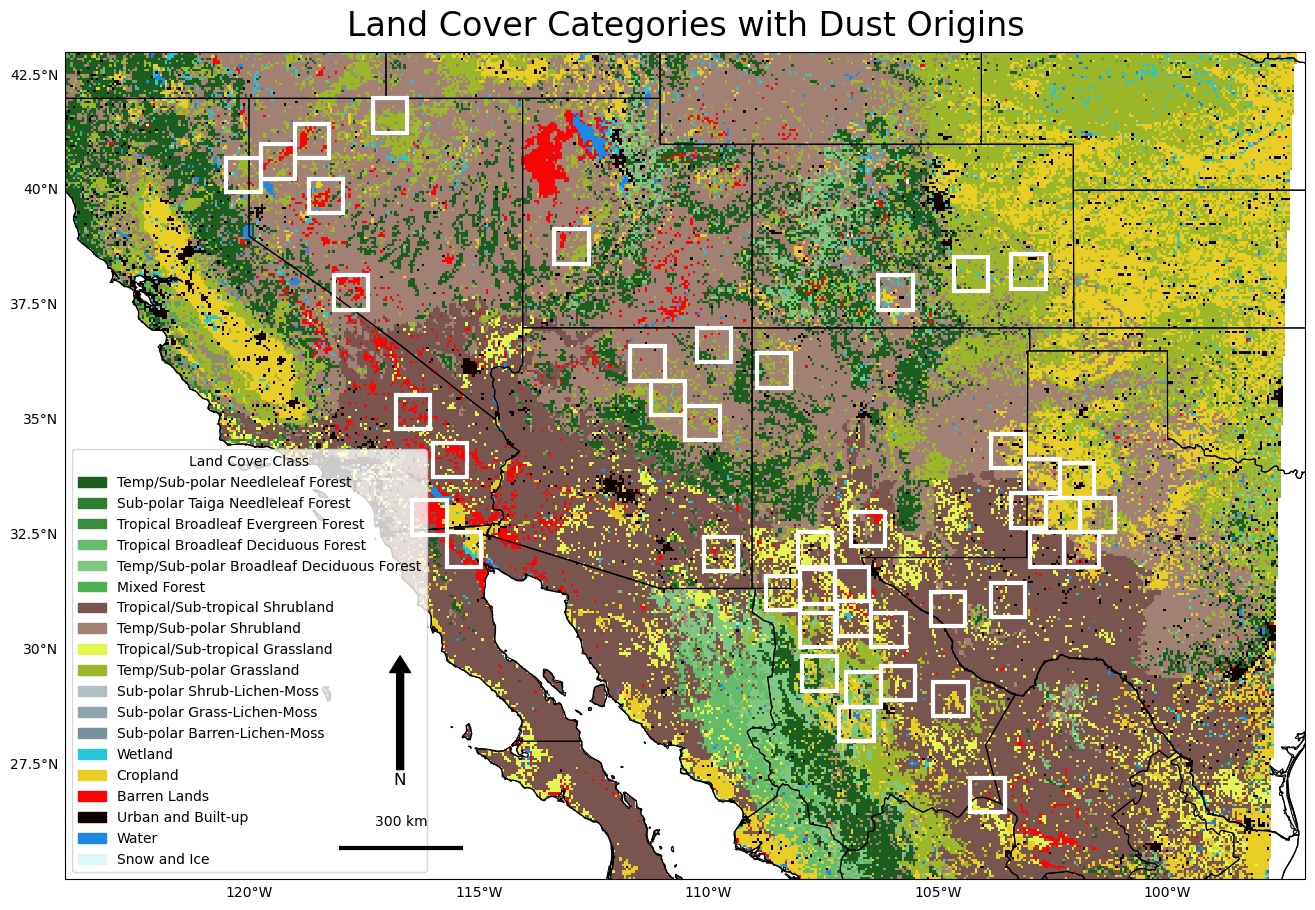

In [12]:
land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()

codes = np.array(sorted(classes))
names = [classes[c][0] for c in codes]
colors = [classes[c][1] for c in codes]

cmap = mcolors.ListedColormap(colors)
cec_ds = cec_ds.where(np.isin(cec_ds, codes)) #--- Null values are not included
norm = mcolors.BoundaryNorm(
    boundaries=np.append(codes - 0.5, codes[-1] + 0.5),
    ncolors=len(colors),
)

fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()},)

cec_ds.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
)

add_squares_to_plot(ax)
add_north_arrow(ax, location=(0.27, 0.27))
add_scale_bar(ax, location=(0.396, 0.21))


ax.set_title("Land Cover Categories with Dust Origins", fontsize=24, pad=12)

all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
    name='admin_1_states_provinces', scale='10m', facecolor='none')
ax.add_feature(all_states_provinces, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False

legend_handles = [
    Patch(color=color, label=name)
    for name, color in zip(names, colors)
]

ax.legend(
    handles=legend_handles,
    title="Land Cover Class",
    loc="lower left",
    frameon=True
)

plt.savefig(f"plots/5_land_cover_cec_1_map.png",
            dpi=600, bbox_inches='tight')
plt.show()

## Wind days over 10 m/s

A few thoughts on this. 
* The dust boxes idea is pretty clunky, doesn't get the message across
* The dust points and wind speeds are on two different grids, but the wind speed grid is curvilinear
* For this reason, it would require some thinking to get a wind grid of dust probability

In [13]:
wind_ds = xr.open_dataset("DATA/processed/2_wind_grid_narr_2026-06-15.nc")


winds_over_10 = (wind_ds['wind_speed'] > 10).sum(dim='time')
total_num_wind_days = len(wind_ds['time'])


In [14]:
from scipy.spatial import cKDTree

#--- ERA5
#lat2d, lon2d = np.meshgrid(wind_ds.latitude.values,wind_ds.longitude.values, indexing="ij")

#--- NARR
lat2d, lon2d = wind_ds.lat.values, wind_ds.lon.values

points = np.column_stack((lat2d.ravel(), lon2d.ravel()))

tree = cKDTree(points)

query_points = np.column_stack((dust_points_vars['latitude'], dust_points_vars['longitude']))
dist, idx = tree.query(query_points)

i, j = np.unravel_index(idx, lat2d.shape)

In [15]:
counts = np.zeros_like(lat2d, dtype=int)

for ii, jj in zip(i, j):
    counts[ii, jj] += 1

/home/jturner/miniconda3/envs/wldas_env/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: divide by zero encountered in divide
  result_data = func(*input_data)
/home/jturner/miniconda3/envs/wldas_env/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: invalid value encountered in divide
  result_data = func(*input_data)


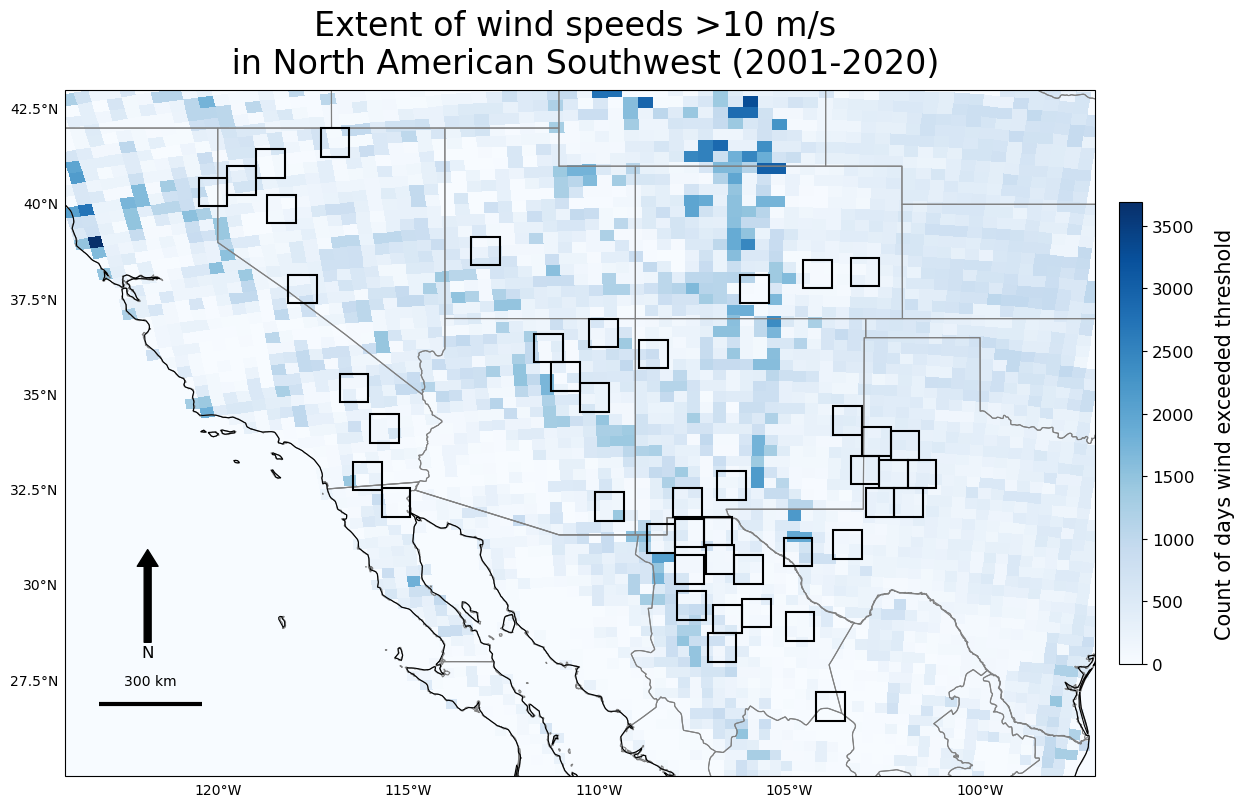

In [17]:
fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()})

#--- Average of wind speeds

# winds_average = wind_ds['wind_speed'].mean(dim='time')

# cf_winds = ax.pcolormesh(
#     winds_average['lon'], 
#     winds_average['lat'],
#     winds_average,
#     transform=ccrs.PlateCarree(),
#     cmap='Blues', #'Greys'
#     vmin=3,
#     vmax=15) 

# cbar_winds = plt.colorbar(cf_winds, ax=ax, orientation='vertical', pad=0.02, shrink=0.5)
# cbar_winds.set_label('wind speed (m/s)', fontsize=15, labelpad=15)
# cbar_winds.ax.tick_params(labelsize=12)

# ax.set_title("Average wind speeds \n in North American Southwest (2001-2020)", fontsize=24, pad=12)

#--- Frequency of wind speeds over 10 m/s

cf_winds = ax.pcolormesh(
    winds_over_10['lon'], 
    winds_over_10['lat'],
    winds_over_10,
    transform=ccrs.PlateCarree(),
    cmap='Blues') #'Greys'

ratio = counts / winds_over_10
ratio = np.ma.masked_where(counts == 0, ratio)

cbar_winds = plt.colorbar(cf_winds, ax=ax, orientation='vertical', pad=0.02, shrink=0.5)
cbar_winds.set_label('Count of days wind exceeded threshold', fontsize=15, labelpad=15)
cbar_winds.ax.tick_params(labelsize=12)

ax.set_title("Extent of wind speeds >10 m/s \n in North American Southwest (2001-2020)", fontsize=24, pad=12)

#--- Dust frequency gridded on wind map

# cf_dust = ax.pcolormesh(
#     winds_over_10['longitude'], 
#     winds_over_10['latitude'],
#     ratio,
#     transform=ccrs.PlateCarree(),
#     cmap='copper_r',
#     vmax=3)

# cbar_dust = plt.colorbar(cf_dust, ax=ax, orientation='vertical', pad=0.0, shrink=0.5)
# cbar_dust.set_label('Dust events per wind event over > 10 m/s', fontsize=15)
# cbar_dust.ax.tick_params(labelsize=12)

#--- Squares

add_squares_to_plot(ax, color="black", linewidth=1.5)

#--- Density scatter plot

# kde = gaussian_kde([dust_points_vars["longitude"], dust_points_vars["latitude"]], bw_method=0.02)
# x = dust_points_vars["longitude"]
# y = dust_points_vars["latitude"]
# z = kde([x, y])
# z = np.array(z)
# colors = plt.cm.jet(np.linspace(0.28, 1.0, 256))
# custom_cmap = LinearSegmentedColormap.from_list('custom', colors)
# norm = plt.Normalize(vmin=z.min(), vmax=z.max())
# scatter = ax.scatter(x, y, c=z, cmap=custom_cmap, s=3, edgecolors='none', alpha=0.8, norm=norm, zorder=6)


add_north_arrow(ax, location=(0.08, 0.33))
add_scale_bar(ax, location=(0.175, 0.175))

all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
    name='admin_1_states_provinces', scale='10m', facecolor='none')
ax.add_feature(all_states_provinces, linewidth=0.8, edgecolor="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="grey")
min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False

plt.savefig(f"plots/1_wind_speed_map_dust_events.png",
            dpi=600, bbox_inches='tight')
plt.show()

## Three combo map

In [18]:
combo_three_ds = xr.open_dataset("DATA/processed/7_surface_combo_dust_2026-06-22.nc")

In [19]:
#--- Apply dictionaries to get the category names

land_cover_dict = common_functions.get_land_cover_dict()
soil_order_dict = common_functions.get_soil_order_names_major()
texture_dict = common_functions.get_texture_dict()

combo_three_ds["combo_id"] = combo_three_ds["combo_id"].astype(int)

def decode_combo_id(combo_id):
    texture = combo_id // 1_000_000
    soil_order = (combo_id % 1_000_000) // 1_000
    surface_cover = combo_id % 1_000
    return texture, soil_order, surface_cover

def combo_id_to_label(combo_id):
    texture, soil, cover = decode_combo_id(combo_id)

    return (
        texture_dict.get(texture, f"Unknown({texture})"),
        soil_order_dict.get(soil, f"Unknown({soil})"),
        land_cover_dict.get(cover, f"Unknown({cover})")
    )

/home/jturner/miniconda3/envs/wldas_env/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [20]:
combo_three_df = combo_three_ds[["combo_id", "dust_event_count"]].to_dataframe().reset_index()

#--- Remove the null row
combo_three_df = combo_three_df[combo_three_df["combo_id"] != -9223372036854775808]

grouped = combo_three_df.groupby("combo_id").agg(
    dust_event_count=("dust_event_count", "sum"),
    full_domain=("combo_id", "size")
)
grouped = grouped.sort_values("dust_event_count", ascending=False)

decoded = [
    (cid, *combo_id_to_label(cid), row.dust_event_count, row.full_domain)
    for cid, row in grouped.iterrows()
]

top_df = pd.DataFrame(
    decoded,
    columns=["combo_id", "texture", "soil_order", "surface_cover", "dust_events", "full_domain"]
)

top_df

,combo_id,texture,soil_order,surface_cover,dust_events,full_domain
0,11003016,Silty Clay,Entisols,Barren Lands,175.0,76.0
1,6003009,Loam,Entisols,Tropical/Sub-tropical Grassland,154.0,1382.0
2,6002007,Loam,Aridisols,Tropical/Sub-tropical Shrubland,139.0,11365.0
3,6003007,Loam,Entisols,Tropical/Sub-tropical Shrubland,123.0,10367.0
4,1002008,Sand,Aridisols,Temp/Sub-polar Shrubland,117.0,1793.0
...,...,...,...,...,...,...
835,6000014,Loam,Alfisols,Wetland,0.0,106.0
836,6000016,Loam,Alfisols,Barren Lands,0.0,18.0
837,6000018,Loam,Alfisols,Water,0.0,41.0
838,6000127,Loam,Alfisols,Unknown(127),0.0,53.0


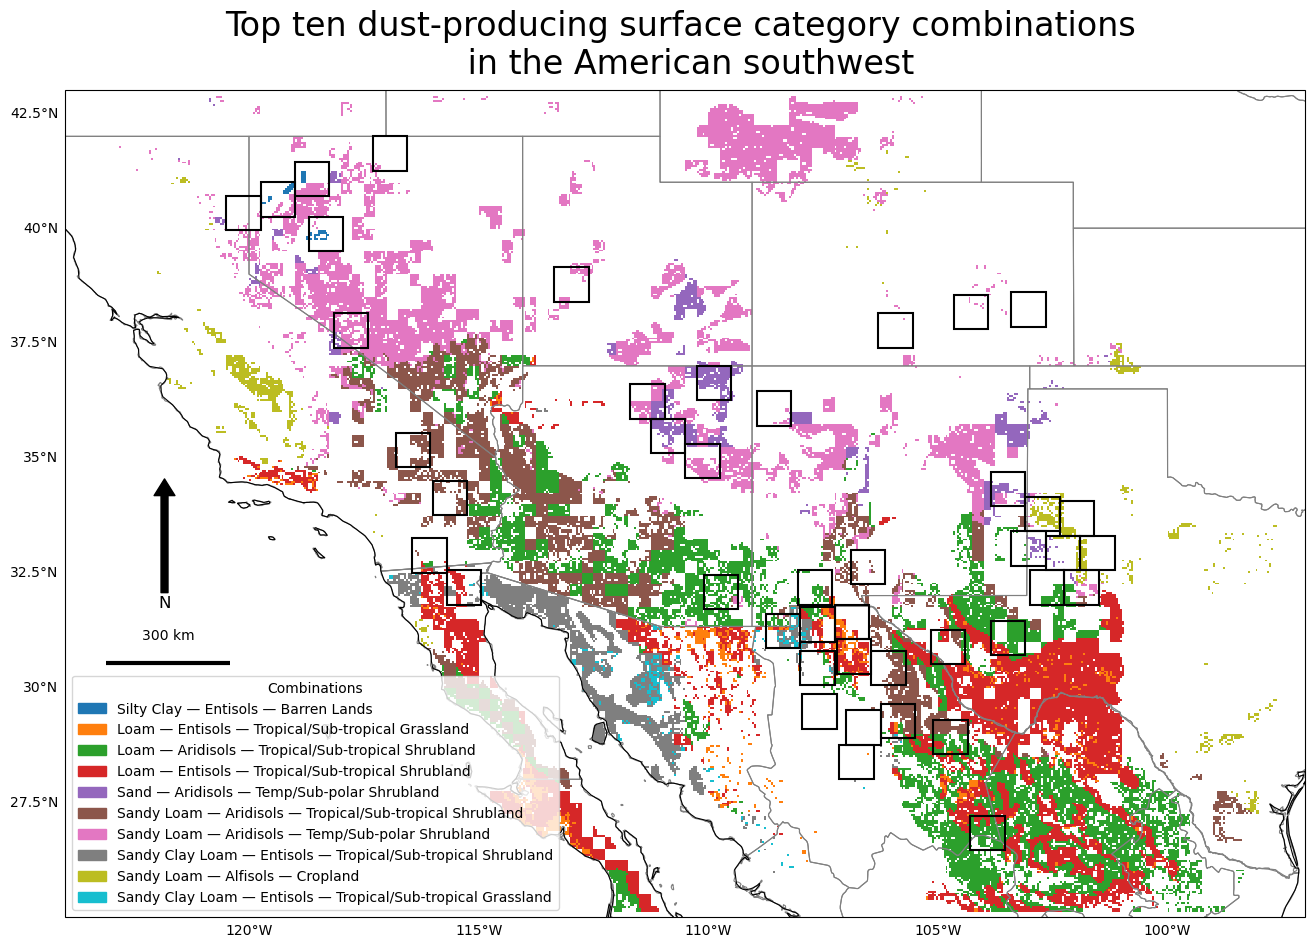

In [21]:
#--- Plot these selected combos on the map
fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()},)

#--- Get the top 10 combo IDs
top_10_df = top_df[:10]
top_ids = top_10_df["combo_id"].values

tab10 = plt.cm.tab10(np.arange(len(top_ids)))
id_to_color = {
    cid: tab10[i]
    for i, cid in enumerate(top_ids)
}

#--- Set other values to transparent
data = combo_three_ds["combo_id"]
combo_id_masked = data.where(np.isin(data, top_ids))

id_to_index = {
    cid: i
    for i, cid in enumerate(top_ids)
}

indexed = xr.full_like(combo_id_masked, fill_value=np.nan, dtype=float)

for cid, idx in id_to_index.items():
    indexed = indexed.where(combo_id_masked != cid, idx)

#--- Create colormap
cmap = mcolors.ListedColormap(tab10)
cmap.set_bad(alpha=0)
norm = mcolors.BoundaryNorm(
    np.arange(len(top_ids) + 1) - 0.5,
    cmap.N
)

mesh = ax.pcolormesh(
    combo_three_ds["lon"],
    combo_three_ds["lat"],
    indexed,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)
    
    
add_squares_to_plot(ax, color="black", linewidth=1.5)
add_north_arrow(ax, location=(0.08, 0.53))
add_scale_bar(ax, location=(0.25, 0.39))

ax.set_title("Top ten dust-producing surface category combinations \n in the American southwest", fontsize=24, pad=12)

all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
    name='admin_1_states_provinces', scale='10m', facecolor='none')
ax.add_feature(all_states_provinces, linewidth=0.8, edgecolor="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="grey")
min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False

legend_handles = [
    Patch(
        color=id_to_color[row["combo_id"]],
        label=(
            f"{row['texture']} — "
            f"{row['soil_order']} — "
            f"{row['surface_cover']}"
        )
    )
    for _, row in top_10_df.iterrows()
]

ax.legend(
    handles=legend_handles,
    title="Combinations",
    loc="lower left",
    frameon=True
)

plt.savefig(f"plots/6_combination_map.png",
            dpi=600, bbox_inches='tight')
plt.show()